<a href="https://colab.research.google.com/github/Felipe-biguzzi/NIAD-/blob/main/projeto_NIAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Importação dos dados coluna vertebral do Kaggle

In [9]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Dataset_spine.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jessanrod3/vertebralcolumndataset",
  file_path,
)


print(df)

/tmp/ipykernel_4191/1354776303.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'vertebralcolumndataset' dataset.
     pelvic incidence   pelvic tilt   lumbar lordosis angle   sacral slope  \
0           63.027817     22.552586               39.609117      40.475232   
1           39.056951     10.060991               25.015378      28.995960   
2           68.832021     22.218482               50.092194      46.613539   
3           69.297008     24.652878               44.311238      44.644130   
4           49.712859      9.652075               28.317406      40.060784   
..                ...           ...                     ...            ...   
305         47.903565     13.616688               36.000000      34.286877   
306         53.936748     20.721496               29.220534      33.215251   
307         61.446597     22.694968               46.170347      38.751628   
308         45.252792      8.693157               41.583126      36.559635   
309         33.841641      5.073991               36.641233      

# 2. Análise inicial dos dados:
- Divisão do banco de dados em 2 grupos, normais e anormais
- Distribuição dos dados de cada variável em função dos grupos
- Matriz de correlação entre variáveis (principal interesse foi averiguar a correlação com a variável "resposta": classificação)
- Teste de significancia estatística entre os grupos (para certificar que as variáveis iriam contribuir para treinamento do modelo)

### 2.1 Divisão do banco de dados em 2 grupos, normais e anormais

In [10]:
from sklearn.preprocessing import LabelEncoder

# Separate features (X) and target (y)
X = df.drop('Class_att', axis=1)
y_raw = df['Class_att']

# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Original Class_att labels:", le.inverse_transform([0, 1]))
print("Encoded target (y) head:", y[:5])

Original Class_att labels: ['Abnormal' 'Normal']
Encoded target (y) head: [0 0 0 0 0]


### 2.2 Distribuição dos dados de cada variável em função dos grupos

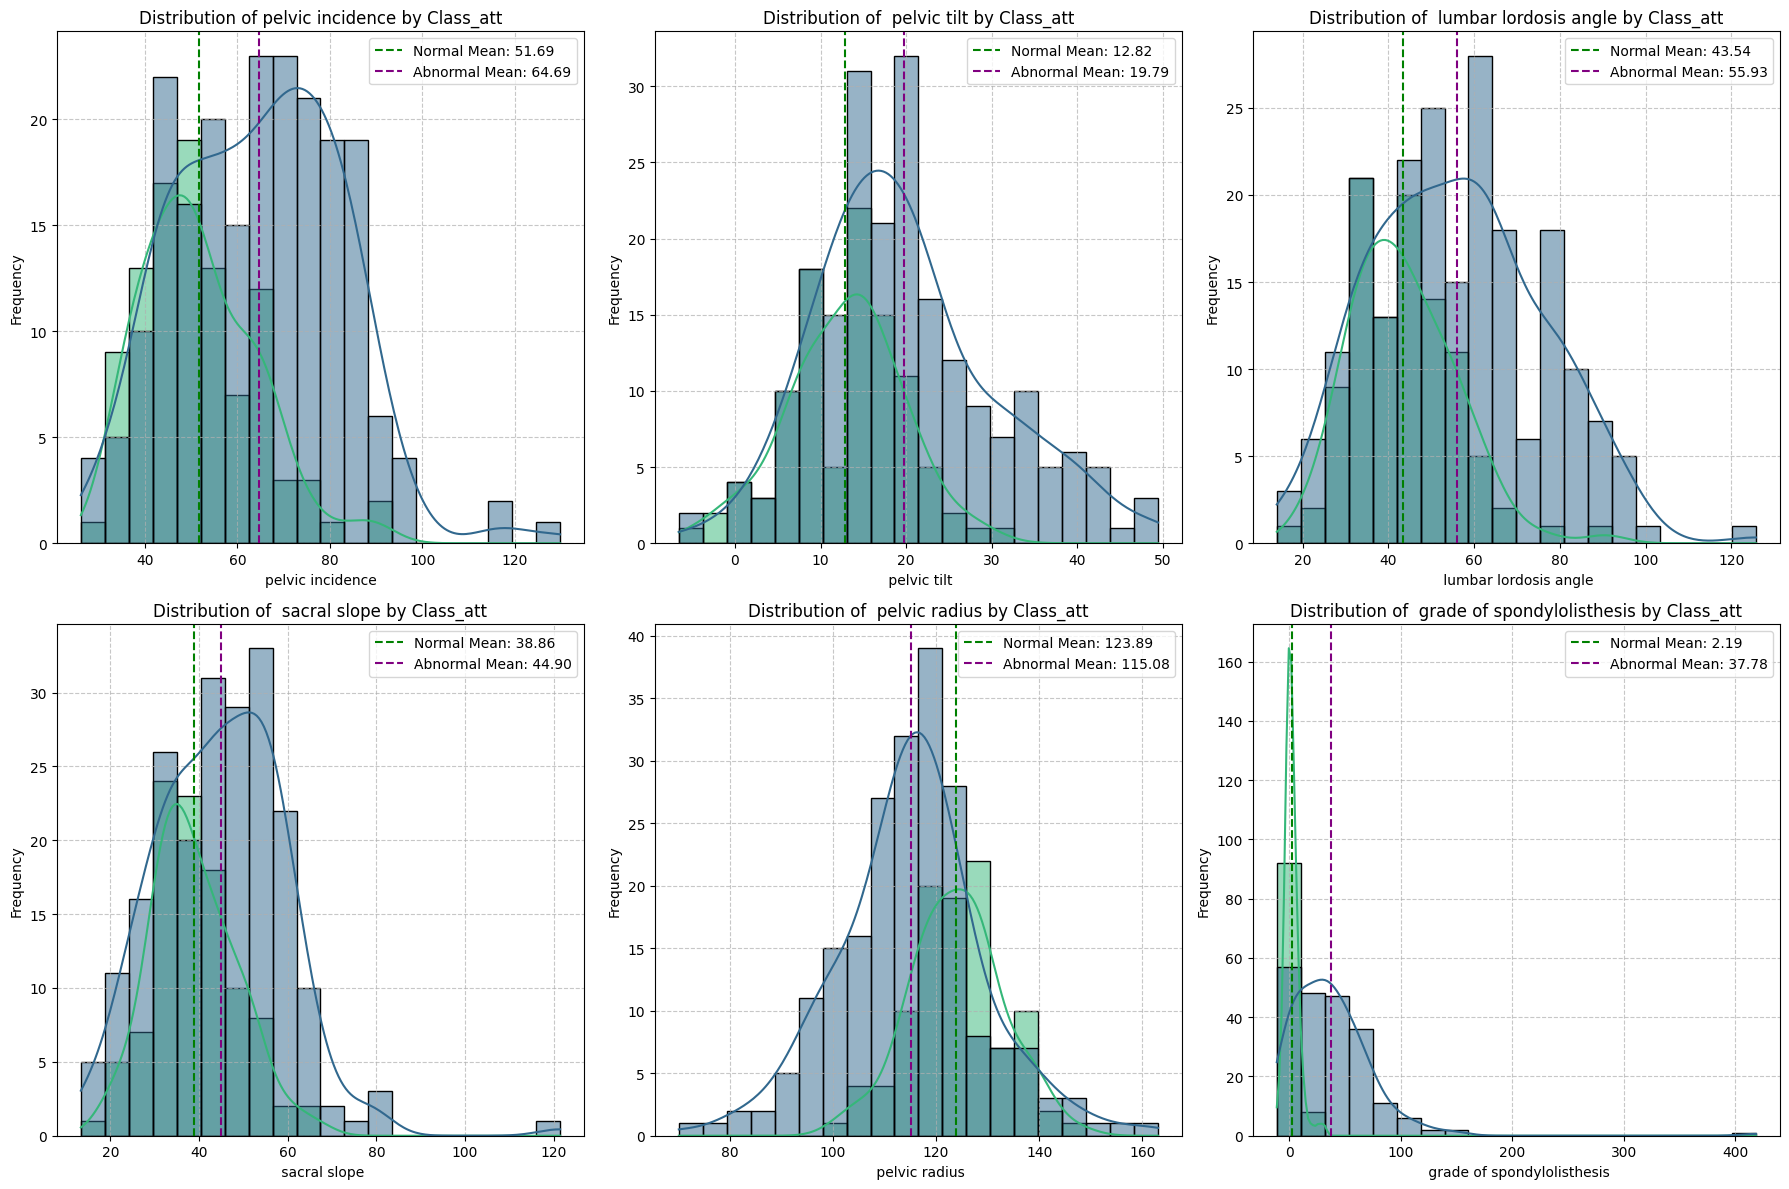

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the feature names from X
feature_columns = X.columns

# Create a figure to hold all subplots
plt.figure(figsize=(18, 12))

# Iterate through each feature column and plot its distribution, separated by Class_att
for i, col in enumerate(feature_columns):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid (assuming 6 features)
    sns.histplot(data=df, x=col, hue='Class_att', kde=True, bins=20, palette='viridis', common_norm=False)
    plt.title(f'Distribution of {col} by Class_att')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Calculate mean and std for Normal and Abnormal groups
    normal_data = df[df['Class_att'] == 'Normal'][col]
    abnormal_data = df[df['Class_att'] == 'Abnormal'][col]

    mean_normal = normal_data.mean()
    std_normal = normal_data.std()
    mean_abnormal = abnormal_data.mean()
    std_abnormal = abnormal_data.std()

    # Add annotations for mean and std
    plt.axvline(mean_normal, color='green', linestyle='--', label=f'Normal Mean: {mean_normal:.2f}')
    plt.axvline(mean_abnormal, color='purple', linestyle='--', label=f'Abnormal Mean: {mean_abnormal:.2f}')




    plt.legend()

plt.tight_layout()
plt.show()

### 2.3 Matriz de correlação entre variáveis

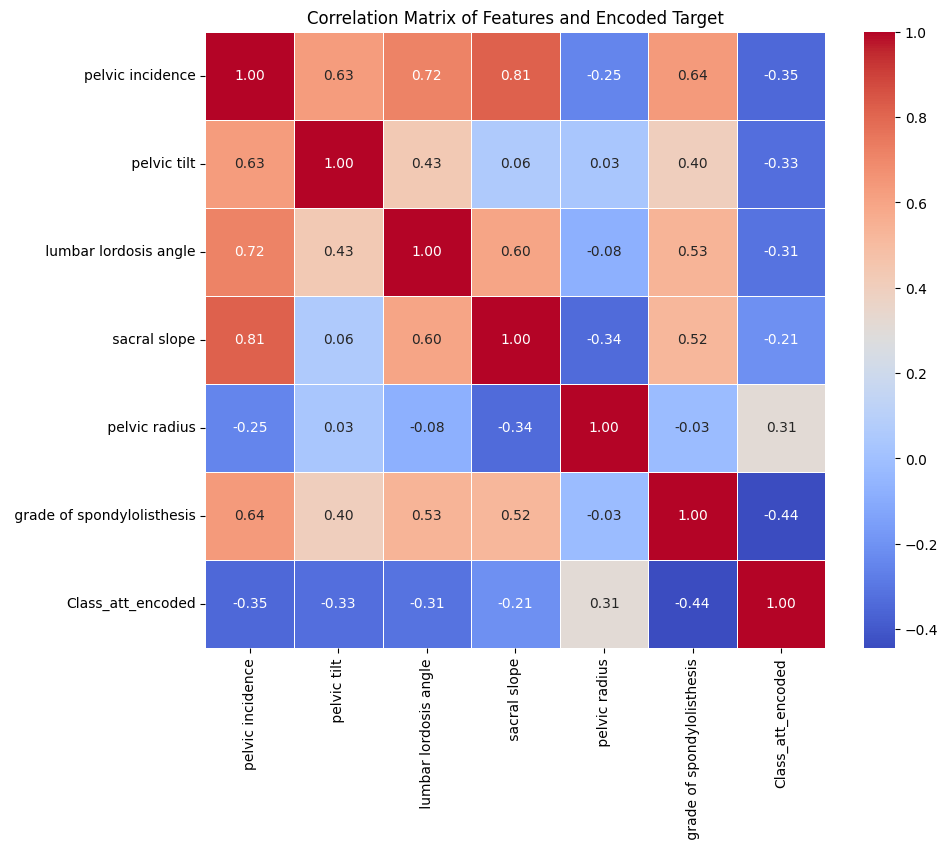

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame that includes features (X) and the encoded target (y)
# Ensure 'y' is a pandas Series with a name for better labeling in the heatmap
df_corr = X.copy()
df_corr['Class_att_encoded'] = pd.Series(y, index=X.index)

# Calculate the correlation matrix
correlation_matrix = df_corr.corr()

# Plot the correlation matrix as a heatmap
fig = plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features and Encoded Target')
plt.show()

This heatmap visualizes the Pearson correlation coefficients between all the features and the encoded target variable ('Class_att_encoded').

*   **Colors**: Red shades indicate positive correlation, blue shades indicate negative correlation, and lighter colors (closer to white) indicate weaker correlation.
*   **Numbers**: The values in each cell represent the correlation coefficient, ranging from -1 (perfect negative correlation) to +1 (perfect positive correlation).
*   **Diagonal**: The diagonal elements are always 1, as a variable is perfectly correlated with itself.

This plot helps identify which features are strongly related to each other and which features have the strongest linear relationship with the target variable.

### 2.4 Teste de significancia estatística entre os grupos

### Statistical Difference Analysis: Normal vs. Abnormal Classes

To further understand the differences between the 'Normal' and 'Abnormal' classes, we can perform independent samples t-tests for each feature. A t-test assesses whether the means of two independent groups are significantly different from each other.

*   **Null Hypothesis (H0):** There is no significant difference in the mean of the feature between the 'Normal' and 'Abnormal' groups.
*   **Alternative Hypothesis (H1):** There is a significant difference in the mean of the feature between the 'Normal' and 'Abnormal' groups.

We will examine the p-value: if the p-value is less than a chosen significance level (e.g., 0.05), we reject the null hypothesis, suggesting a statistically significant difference.

In [13]:
from scipy.stats import ttest_ind

# Separate the DataFrame by 'Class_att'
df_normal = df[df['Class_att'] == 'Normal']
df_abnormal = df[df['Class_att'] == 'Abnormal']

print("\nIndependent Samples t-test Results (Normal vs. Abnormal):\n")

# Perform t-test for each feature
for column in X.columns:
    stat, p_value = ttest_ind(df_normal[column], df_abnormal[column])
    print(f"Feature: {column}")
    print(f"  t-statistic: {stat:.4f}")
    print(f"  p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"  -> Significant difference (p < 0.05)\n")
    else:
        print(f"  -> No significant difference (p >= 0.05)\n")


Independent Samples t-test Results (Normal vs. Abnormal):

Feature: pelvic incidence
  t-statistic: -6.6286
  p-value: 0.0000
  -> Significant difference (p < 0.05)

Feature:  pelvic tilt
  t-statistic: -6.0532
  p-value: 0.0000
  -> Significant difference (p < 0.05)

Feature:  lumbar lordosis angle
  t-statistic: -5.7732
  p-value: 0.0000
  -> Significant difference (p < 0.05)

Feature:  sacral slope
  t-statistic: -3.7808
  p-value: 0.0002
  -> Significant difference (p < 0.05)

Feature:  pelvic radius
  t-statistic: 5.7195
  p-value: 0.0000
  -> Significant difference (p < 0.05)

Feature:  grade of spondylolisthesis
  t-statistic: -8.6887
  p-value: 0.0000
  -> Significant difference (p < 0.05)



The independent samples t-test results indicate that for all features ('pelvic incidence', 'pelvic tilt', 'lumbar lordosis angle', 'sacral slope', 'pelvic radius', and 'grade of spondylolisthesis'), there is a statistically significant difference (p < 0.05) between the 'Normal' and 'Abnormal' groups. This suggests that these features are important in distinguishing between the two classes.

# 3. Aplicação do modelo de regressão logística para treino e teste de aprendizagem

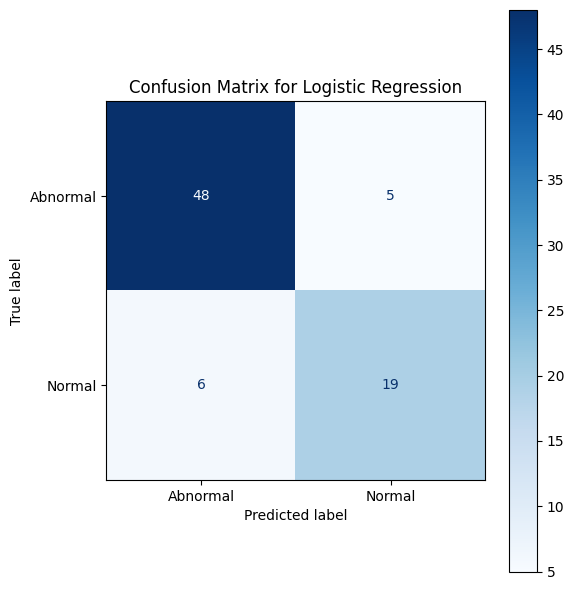

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Split the data into training and testing sets
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Initialize and train a Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train_clf, y_train_clf)

# Make predictions on the test set
y_pred_clf = model.predict(X_test_clf)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(
    model, X_test_clf, y_test_clf, cmap='Blues', ax=ax,
    display_labels=le.inverse_transform(model.classes_)
)
ax.set_title('Confusion Matrix for Logistic Regression')
plt.tight_layout()
plt.show()

## 3.1 Métricas de eficiência do modelo

### Acurácea, precisão, recall  (sensibilidade), score F1

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.8590
Precision: 0.7917
Recall: 0.7600
F1-score: 0.7755


### Curva ROC e ACU (área em baixo da curva)

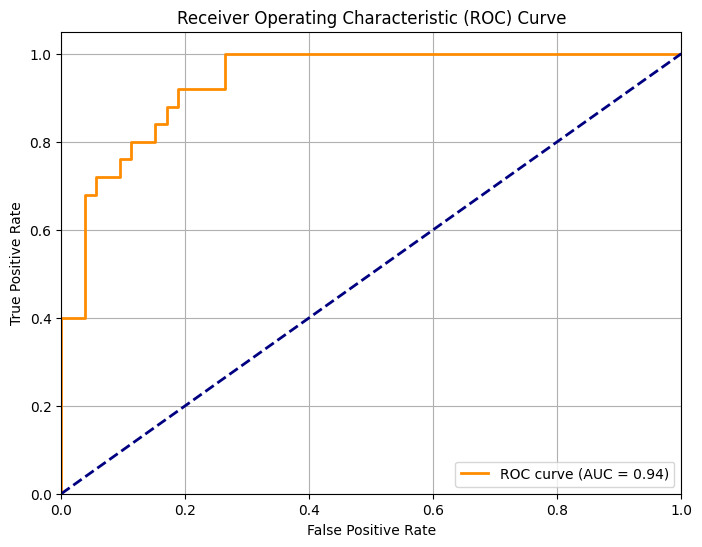

AUC Score: 0.9374


In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_pred_proba = model.predict_proba(X_test_clf)[:, 1]

# Calculate ROC curve metrics
fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
fig = plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

### Receiver Operating Characteristic (ROC) Curve Analysis

The **Receiver Operating Characteristic (ROC) curve** is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots two parameters:

*   **True Positive Rate (TPR)**: Also known as sensitivity or recall, it's the proportion of actual positive cases that are correctly identified as positive.
*   **False Positive Rate (FPR)**: It's the proportion of actual negative cases that are incorrectly identified as positive.

An ideal classifier would have a curve that goes straight up the y-axis (TPR) and then straight across the top of the x-axis (FPR), indicating a high true positive rate and a low false positive rate. The **Area Under the Curve (AUC)** is a measure of the entire two-dimensional area underneath the entire ROC curve. It provides an aggregate measure of performance across all possible classification thresholds. An AUC of 1.0 represents a perfect classifier, while an AUC of 0.5 suggests a classifier with no discriminative ability (equivalent to random guessing).

## 3.2 Contribuição de cada variável utilizado pelo modelo

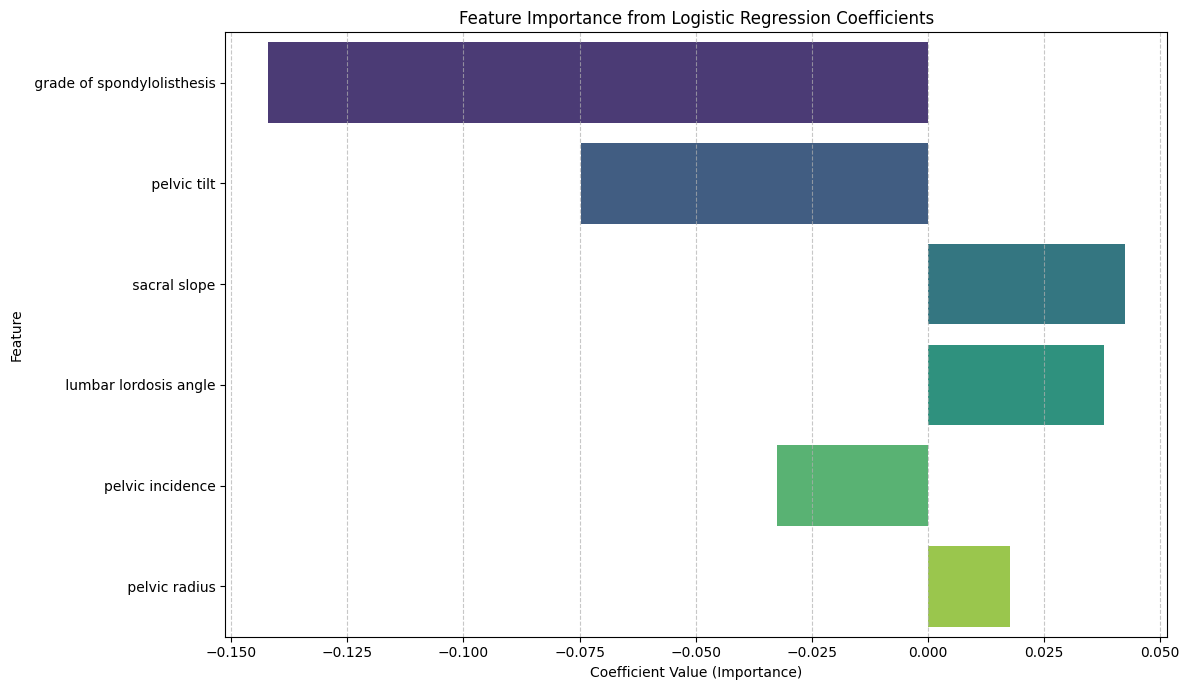

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature names from X_train_clf
feature_names = X_train_clf.columns

# Get coefficients from the trained model
# For Logistic Regression, coefficients represent feature importance
coefficients = model.coef_[0]

# Create a DataFrame to store feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

# Sort by absolute importance to see the most influential features
feature_importance['Absolute_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Absolute_Importance', ascending=False)

# Plotting feature importance
fig = plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance from Logistic Regression Coefficients')
plt.xlabel('Coefficient Value (Importance)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation of Logistic Regression Coefficients

In a Logistic Regression model, the coefficients associated with each feature indicate the strength and direction of the relationship between that feature and the **log-odds** of the target variable (which in our case is 'Normal' vs 'Abnormal').

*   **Positive Coefficient**: A positive coefficient indicates that as the value of the feature increases, the log-odds of the target variable being 'Normal' also increases. This means the feature is positively associated with the 'Normal' class. All other factors being equal, higher values of such a feature make it more likely for the instance to be classified as 'Normal'.

*   **Negative Coefficient**: Conversely, a negative coefficient indicates that as the value of the feature increases, the log-odds of the target variable being 'Normal' decreases. This means the feature is negatively associated with the 'Normal' class, or positively associated with the 'Abnormal' class. Higher values of such a feature make it more likely for the instance to be classified as 'Abnormal'.

# 4. Testando novo modelo
Para esse  modelo foi utilizado apenas os 3 parâmetros que contribuiram para escolha do grupo anormal (grade of spondylolisthesis, pelvic tilt, pelvic incidence)

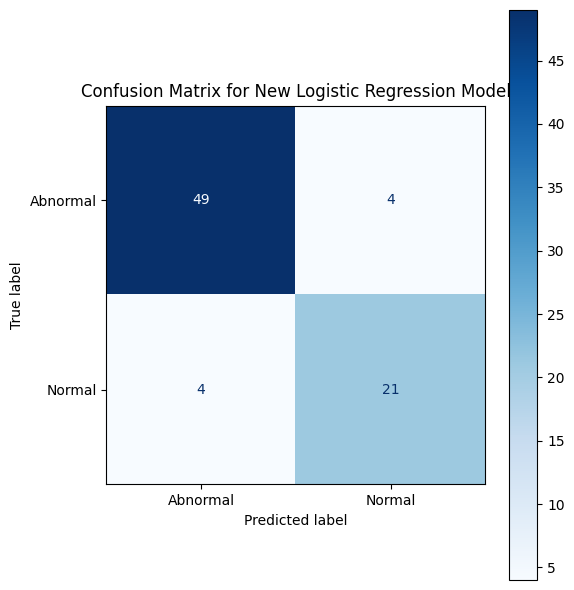

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Select the new set of features
selected_features = [' grade of spondylolisthesis', ' pelvic tilt', 'pelvic incidence']
X_new = df[selected_features]

# Split the data into training and testing sets for the new model
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y, test_size=0.25, random_state=42, stratify=y
)

# Initialize and train a new Logistic Regression model
model_new = LogisticRegression(random_state=42, solver='liblinear')
model_new.fit(X_train_new, y_train_new)

# Make predictions on the test set
y_pred_new = model_new.predict(X_test_new)

# Display the confusion matrix for the new model
fig_new_cm, ax_new_cm = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(
    model_new, X_test_new, y_test_new, cmap='Blues', ax=ax_new_cm,
    display_labels=le.inverse_transform(model_new.classes_)
)
ax_new_cm.set_title('Confusion Matrix for New Logistic Regression Model')
plt.tight_layout()
plt.show()

## 4.1 Métricas de eficiência do modelo

### Acurácea, precisão, recall  (sensibilidade), score F1

In [23]:
# Calculate and print performance metrics for the new model
accuracy_new = accuracy_score(y_test_new, y_pred_new)
precision_new = precision_score(y_test_new, y_pred_new)
recall_new = recall_score(y_test_new, y_pred_new)
f1_new = f1_score(y_test_new, y_pred_new)

print(f"Accuracy (New Model): {accuracy_new:.4f}")
print(f"Precision (New Model): {precision_new:.4f}")
print(f"Recall (New Model): {recall_new:.4f}")
print(f"F1-score (New Model): {f1_new:.4f}")

Accuracy (New Model): 0.8974
Precision (New Model): 0.8400
Recall (New Model): 0.8400
F1-score (New Model): 0.8400


### Curva ROC e ACU (área em baixo da curva)

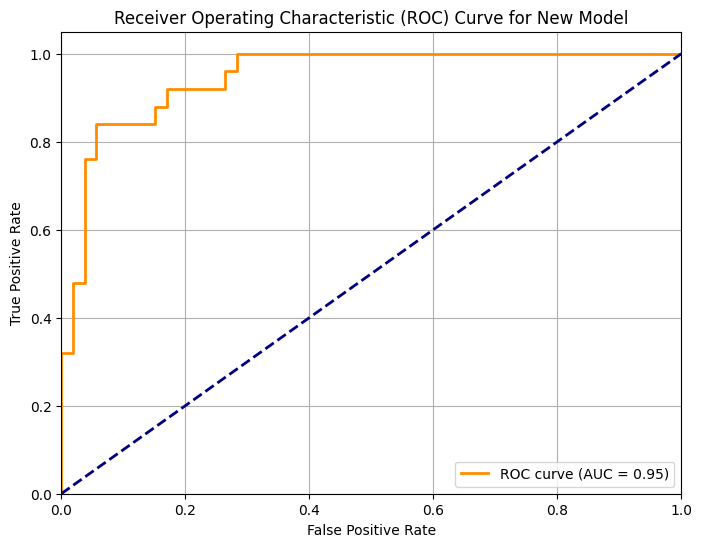

AUC Score (New Model): 0.9472


In [26]:
# Get predicted probabilities for the positive class (New Model)
y_pred_proba_new = model_new.predict_proba(X_test_new)[:, 1]

# Calculate ROC curve metrics (New Model)
fpr_new, tpr_new, thresholds_new = roc_curve(y_test_new, y_pred_proba_new)
roc_auc_new = auc(fpr_new, tpr_new)

# Plot the ROC curve (New Model)
fig_new_roc = plt.figure(figsize=(8, 6))
plt.plot(fpr_new, tpr_new, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_new:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for New Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC Score (New Model): {roc_auc_new:.4f}")

## 4.2 Contribuição de cada variável utilizado pelo modelo

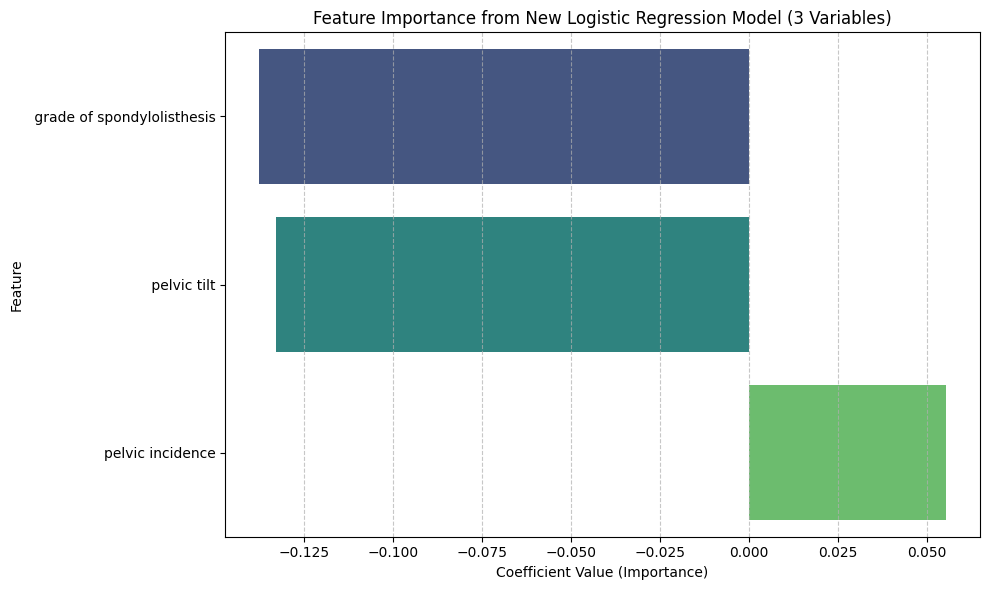

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature names from the selected_features list used for model_new
feature_names_new = selected_features

# Get coefficients from the trained new model
# For Logistic Regression, coefficients represent feature importance
coefficients_new = model_new.coef_[0]

# Create a DataFrame to store feature importance for the new model
feature_importance_new = pd.DataFrame({
    'Feature': feature_names_new,
    'Importance': coefficients_new
})

# Sort by absolute importance to see the most influential features
feature_importance_new['Absolute_Importance'] = feature_importance_new['Importance'].abs()
feature_importance_new = feature_importance_new.sort_values(by='Absolute_Importance', ascending=False)

# Plotting feature importance for the new model
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_new, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance from New Logistic Regression Model (3 Variables)')
plt.xlabel('Coefficient Value (Importance)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 4.3 Magnitude da diferença entre grupos para os 3 parâmetros do novo modelo
- Foi utilizado teste Cohen's d e o teste de poder estatistico do teste de significancia (teste T) para certificar que o tamnho da amostra (N) era suficientemente grande para sustentar esses resultados em longo prazo, ou seja, que o modelo não incorreria em vicios decorrentes de N insuficiente.
- Certo dessa estabilidade, a utilização dos demais parametros também se tornda desnecessária para a estabilidade do modelo. variáveis apresentaram grande poder de diferenciação entre os grupo, ou seja, além de siginificativamente diferentes, são expressivamente diferentes.

### Statistical Power Analysis for Feature Differences

To understand if our current sample size is sufficient to detect significant differences, we will perform a post-hoc statistical power analysis. We'll focus on the independent samples t-test that was previously conducted to compare the 'Normal' and 'Abnormal' classes for the 'grade of spondylolisthesis' feature, which was identified as highly important.

In [29]:
from statsmodels.stats.power import TTestIndPower
import numpy as np

# --- Parameters for Power Analysis for 'grade of spondylolisthesis' ---

# Sample sizes for 'Normal' and 'Abnormal' groups
n_normal = len(df_normal[' grade of spondylolisthesis'])
n_abnormal = len(df_abnormal[' grade of spondylolisthesis'])

# Means and standard deviations from previous analysis (cell b79f6704 outputs)
mean_normal_gs = df_normal[' grade of spondylolisthesis'].mean()
std_normal_gs = df_normal[' grade of spondylolisthesis'].std()

mean_abnormal_gs = df_abnormal[' grade of spondylolisthesis'].mean()
std_abnormal_gs = df_abnormal[' grade of spondylolisthesis'].std()

# Significance level (alpha)
alpha = 0.05

# Calculate pooled standard deviation
pool_std = np.sqrt(((n_normal - 1) * std_normal_gs**2 + (n_abnormal - 1) * std_abnormal_gs**2) / (n_normal + n_abnormal - 2))

# Calculate Cohen's d (effect size)
cohens_d = (mean_abnormal_gs - mean_normal_gs) / pool_std

# Initialize power analysis object
power_analysis = TTestIndPower()

# Calculate power
power = power_analysis.solve_power(
    effect_size=cohens_d,
    nobs1=n_normal,
    alpha=alpha,
    ratio=n_abnormal / n_normal, # ratio of sample sizes (n2/n1)
    alternative='two-sided' # Two-sided test (as t-test was two-sided)
)

print(f"Feature: 'grade of spondylolisthesis'")
print(f"  Mean Normal: {mean_normal_gs:.2f}, Std Normal: {std_normal_gs:.2f}")
print(f"  Mean Abnormal: {mean_abnormal_gs:.2f}, Std Abnormal: {std_abnormal_gs:.2f}")
print(f"  Sample size Normal: {n_normal}, Sample size Abnormal: {n_abnormal}")
print(f"  Calculated Cohen's d (Effect Size): {cohens_d:.3f}")
print(f"  Statistical Power for t-test (alpha={alpha}): {power:.3f}")

# Interpretation
if power >= 0.8:
    print("  -> High power: There was a high probability of detecting this effect if it truly exists.")
else:
    print("  -> Lower power: There was a lower probability of detecting this effect. This could mean either the effect is truly small, or our sample size is insufficient to reliably detect it.")

Feature: 'grade of spondylolisthesis'
  Mean Normal: 2.19, Std Normal: 6.31
  Mean Abnormal: 37.78, Std Abnormal: 40.70
  Sample size Normal: 100, Sample size Abnormal: 210
  Calculated Cohen's d (Effect Size): 1.056
  Statistical Power for t-test (alpha=0.05): 1.000
  -> High power: There was a high probability of detecting this effect if it truly exists.


In [30]:
# --- Parameters for Power Analysis for 'pelvic tilt' ---

# Means and standard deviations for 'pelvic tilt'
mean_normal_pt = df_normal[' pelvic tilt'].mean()
std_normal_pt = df_normal[' pelvic tilt'].std()

mean_abnormal_pt = df_abnormal[' pelvic tilt'].mean()
std_abnormal_pt = df_abnormal[' pelvic tilt'].std()

# Calculate pooled standard deviation
pool_std_pt = np.sqrt(((n_normal - 1) * std_normal_pt**2 + (n_abnormal - 1) * std_abnormal_pt**2) / (n_normal + n_abnormal - 2))

# Calculate Cohen's d (effect size)
cohens_d_pt = (mean_abnormal_pt - mean_normal_pt) / pool_std_pt

# Calculate power
power_pt = power_analysis.solve_power(
    effect_size=cohens_d_pt,
    nobs1=n_normal,
    alpha=alpha,
    ratio=n_abnormal / n_normal,
    alternative='two-sided'
)

print(f"\nFeature: 'pelvic tilt'")
print(f"  Mean Normal: {mean_normal_pt:.2f}, Std Normal: {std_normal_pt:.2f}")
print(f"  Mean Abnormal: {mean_abnormal_pt:.2f}, Std Abnormal: {std_abnormal_pt:.2f}")
print(f"  Sample size Normal: {n_normal}, Sample size Abnormal: {n_abnormal}")
print(f"  Calculated Cohen's d (Effect Size): {cohens_d_pt:.3f}")
print(f"  Statistical Power for t-test (alpha={alpha}): {power_pt:.3f}")

# Interpretation
if power_pt >= 0.8:
    print("  -> High power: There was a high probability of detecting this effect if it truly exists.")
else:
    print("  -> Lower power: There was a lower probability of detecting this effect. This could mean either the effect is truly small, or our sample size is insufficient to reliably detect it.")


Feature: 'pelvic tilt'
  Mean Normal: 12.82, Std Normal: 6.78
  Mean Abnormal: 19.79, Std Abnormal: 10.52
  Sample size Normal: 100, Sample size Abnormal: 210
  Calculated Cohen's d (Effect Size): 0.735
  Statistical Power for t-test (alpha=0.05): 1.000
  -> High power: There was a high probability of detecting this effect if it truly exists.


In [31]:
# --- Parameters for Power Analysis for 'pelvic incidence' ---

# Means and standard deviations for 'pelvic incidence'
mean_normal_pi = df_normal['pelvic incidence'].mean()
std_normal_pi = df_normal['pelvic incidence'].std()

mean_abnormal_pi = df_abnormal['pelvic incidence'].mean()
std_abnormal_pi = df_abnormal['pelvic incidence'].std()

# Calculate pooled standard deviation
pool_std_pi = np.sqrt(((n_normal - 1) * std_normal_pi**2 + (n_abnormal - 1) * std_abnormal_pi**2) / (n_normal + n_abnormal - 2))

# Calculate Cohen's d (effect size)
cohens_d_pi = (mean_abnormal_pi - mean_normal_pi) / pool_std_pi

# Calculate power
power_pi = power_analysis.solve_power(
    effect_size=cohens_d_pi,
    nobs1=n_normal,
    alpha=alpha,
    ratio=n_abnormal / n_normal,
    alternative='two-sided'
)

print(f"\nFeature: 'pelvic incidence'")
print(f"  Mean Normal: {mean_normal_pi:.2f}, Std Normal: {std_normal_pi:.2f}")
print(f"  Mean Abnormal: {mean_abnormal_pi:.2f}, Std Abnormal: {std_abnormal_pi:.2f}")
print(f"  Sample size Normal: {n_normal}, Sample size Abnormal: {n_abnormal}")
print(f"  Calculated Cohen's d (Effect Size): {cohens_d_pi:.3f}")
print(f"  Statistical Power for t-test (alpha={alpha}): {power_pi:.3f}")

# Interpretation
if power_pi >= 0.8:
    print("  -> High power: There was a high probability of detecting this effect if it truly exists.")
else:
    print("  -> Lower power: There was a lower probability of detecting this effect. This could mean either the effect is truly small, or our sample size is insufficient to reliably detect it.")


Feature: 'pelvic incidence'
  Mean Normal: 51.69, Std Normal: 12.37
  Mean Abnormal: 64.69, Std Abnormal: 17.66
  Sample size Normal: 100, Sample size Abnormal: 210
  Calculated Cohen's d (Effect Size): 0.805
  Statistical Power for t-test (alpha=0.05): 1.000
  -> High power: There was a high probability of detecting this effect if it truly exists.


For all three top features ('grade of spondylolisthesis', 'pelvic tilt', and 'pelvic incidence'), the power analysis indicates that our current sample size is more than sufficient to detect the observed differences between the Normal and Abnormal groups. This gives us confidence in the statistical significance of these feature differences.

## 4.4 Distribuição dos dados de cada parâmetro em função da respota do modelo



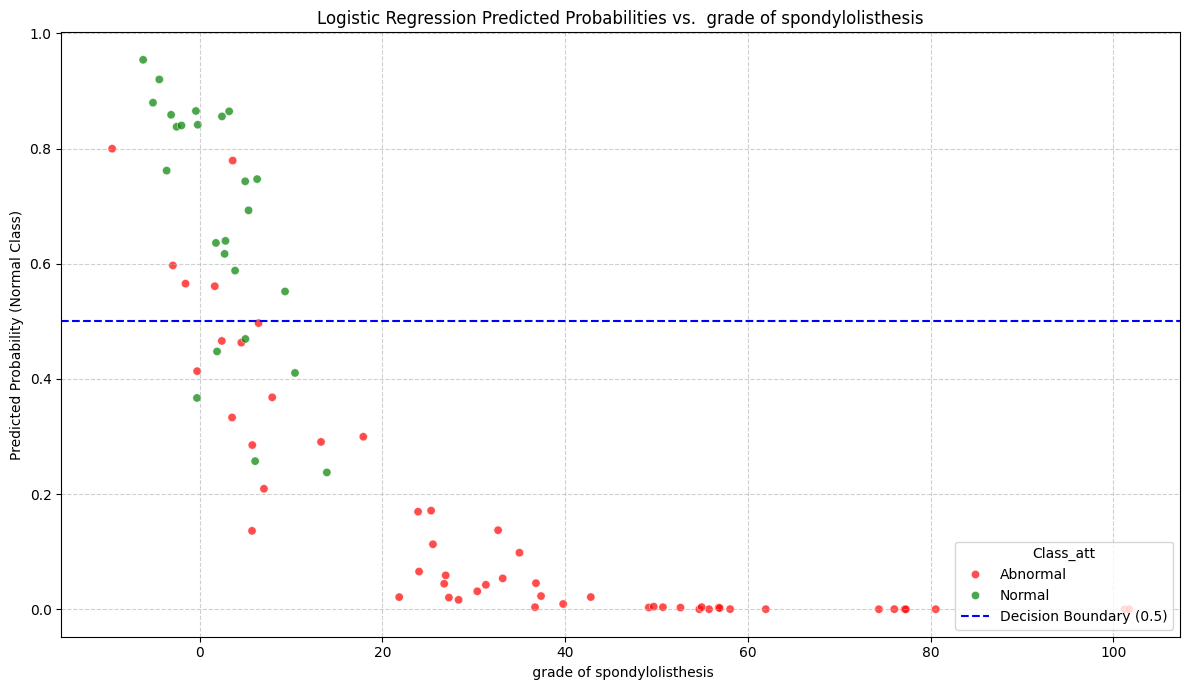

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get predicted probabilities for the positive class (Abnormal, which is encoded as 0)
# Assuming 'Abnormal' is the positive class. From 'y_raw' and 'le.inverse_transform([0, 1])', 'Abnormal' is 0, 'Normal' is 1.
# However, typically the positive class for ROC is 1. Let's ensure consistency.
# From the confusion matrix labels and ROC curve, 'Normal' is treated as positive class (1).
# So we need probabilities for class 1.
y_pred_proba_positive_class = model.predict_proba(X_test_clf)[:, 1]

# Get the most important feature from the feature_importance DataFrame
# The most important feature based on previous analysis is 'grade of spondylolisthesis'
# We need to get the actual feature data for the test set.
most_important_feature_name = ' grade of spondylolisthesis'
feature_data_test = X_test_clf[most_important_feature_name]

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    most_important_feature_name: feature_data_test,
    'Predicted Probability (Normal)': y_pred_proba_positive_class,
    'Actual Class': le.inverse_transform(y_test_clf)
})

# Plotting the logistic regression curve
fig = plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=plot_df,
    x=most_important_feature_name,
    y='Predicted Probability (Normal)',
    hue='Actual Class',
    palette={'Normal': 'green', 'Abnormal': 'red'},
    alpha=0.7
)

# Add the decision boundary at 0.5 probability
plt.axhline(0.5, color='blue', linestyle='--', label='Decision Boundary (0.5)')

plt.title(f'Logistic Regression Predicted Probabilities vs. {most_important_feature_name}')
plt.xlabel(most_important_feature_name)
plt.ylabel('Predicted Probability (Normal Class)')
plt.legend(title='Class_att', loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

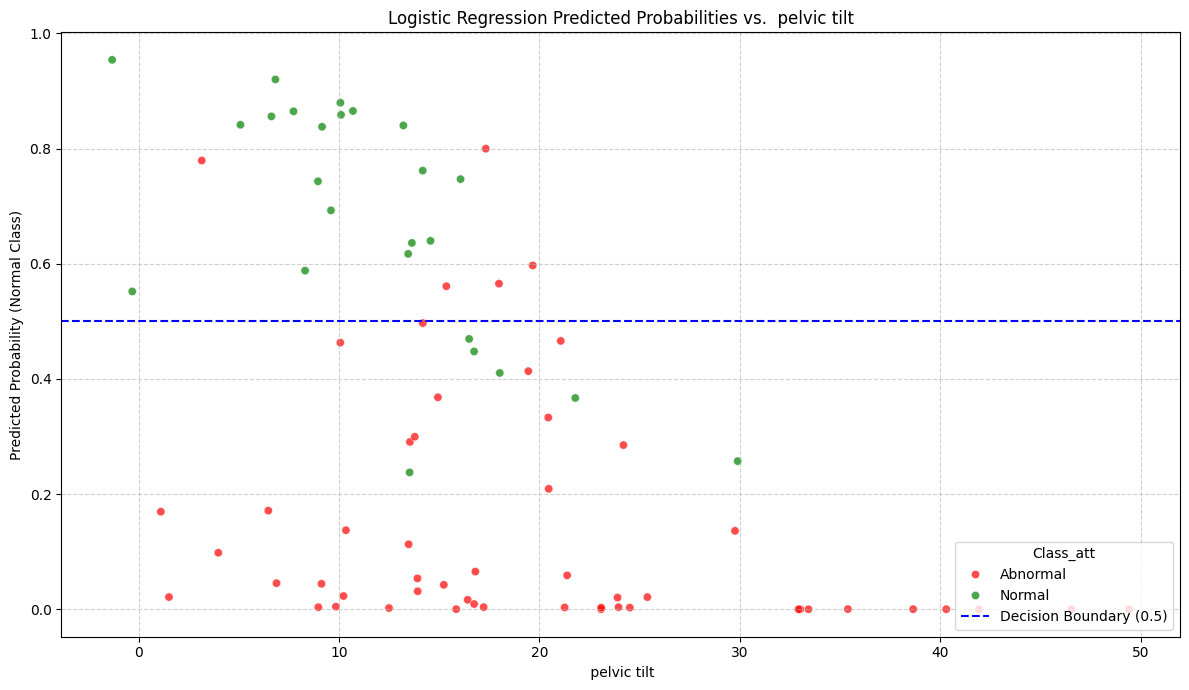

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

feature_to_plot_pt = ' pelvic tilt'
feature_data_test_pt = X_test_clf[feature_to_plot_pt]

plot_df_pt = pd.DataFrame({
    feature_to_plot_pt: feature_data_test_pt,
    'Predicted Probability (Normal)': y_pred_proba_positive_class,
    'Actual Class': le.inverse_transform(y_test_clf)
})

fig_pt = plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=plot_df_pt,
    x=feature_to_plot_pt,
    y='Predicted Probability (Normal)',
    hue='Actual Class',
    palette={'Normal': 'green', 'Abnormal': 'red'},
    alpha=0.7
)

plt.axhline(0.5, color='blue', linestyle='--', label='Decision Boundary (0.5)')

plt.title(f'Logistic Regression Predicted Probabilities vs. {feature_to_plot_pt}')
plt.xlabel(feature_to_plot_pt)
plt.ylabel('Predicted Probability (Normal Class)')
plt.legend(title='Class_att', loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

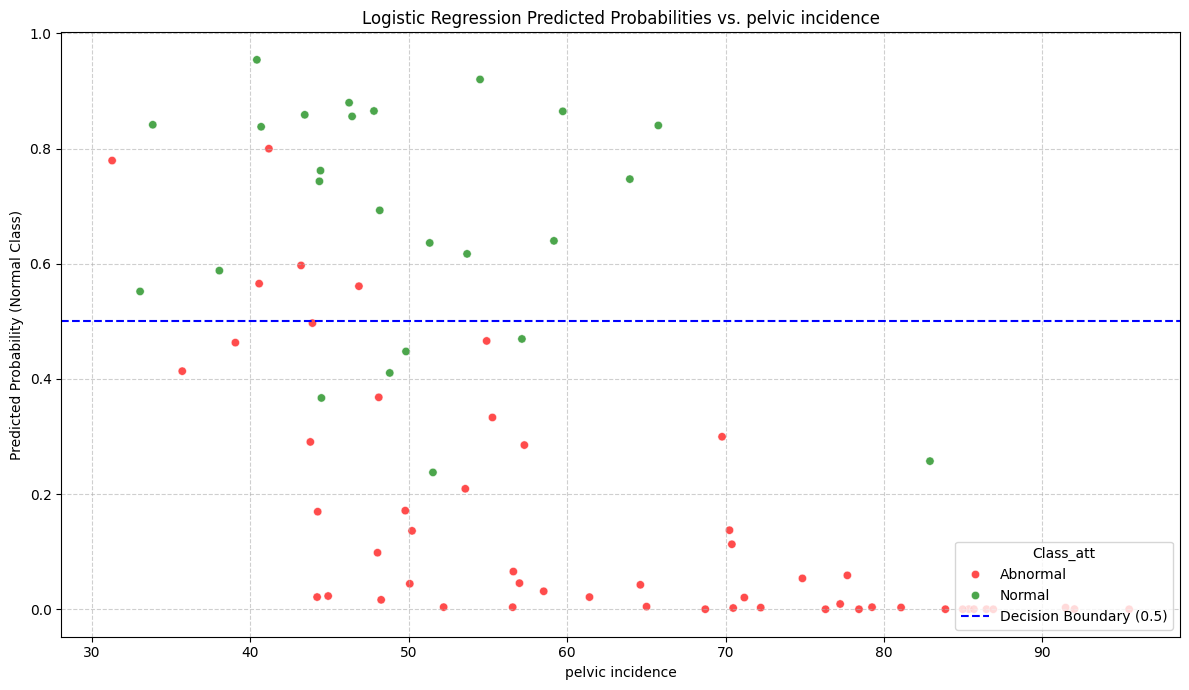

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

feature_to_plot_pi = 'pelvic incidence'
feature_data_test_pi = X_test_clf[feature_to_plot_pi]

plot_df_pi = pd.DataFrame({
    feature_to_plot_pi: feature_data_test_pi,
    'Predicted Probability (Normal)': y_pred_proba_positive_class,
    'Actual Class': le.inverse_transform(y_test_clf)
})

fig_pi = plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=plot_df_pi,
    x=feature_to_plot_pi,
    y='Predicted Probability (Normal)',
    hue='Actual Class',
    palette={'Normal': 'green', 'Abnormal': 'red'},
    alpha=0.7
)

plt.axhline(0.5, color='blue', linestyle='--', label='Decision Boundary (0.5)')

plt.title(f'Logistic Regression Predicted Probabilities vs. {feature_to_plot_pi}')
plt.xlabel(feature_to_plot_pi)
plt.ylabel('Predicted Probability (Normal Class)')
plt.legend(title='Class_att', loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Conclusões finais

### - A necessidade de menos parâmetros para diagnóstico de problemas de coluna reduziu a taxa de erros de diagnóstico de 14% (11 em 78) para 10% (8 em 78).
### - O uso de menos parâmetros também reduz o trabalho, tempo e energia envolvidos nesse processo.
### - Os parametros selecionados se mostraram eficientes e expressivamente diferentes entre grupos, indicando que o modelo não incorrerá em vicios que poderiam comprometer a eficiência do modelo em longo prazo.